# Аудит датасета и протокол dataset v2

Этот ноутбук продолжает исследовательскую цепочку после первого benchmark: перед следующими ML-экспериментами фиксируем качество данных, drift, leakage-risk и правила формирования dataset v2.

Цель этого ноутбука:

- проверить `training_dataset_v1.csv` как источник для следующего benchmark;
- зафиксировать target drift, source drift и неравномерную доступность погодных признаков;
- собрать feature registry с решением, какие признаки можно использовать в dataset v2;
- собрать локальные ignored-артефакты dataset v2;
- не обучать ML-модели и не сравнивать их с baseline на этом шаге.

Следующий шаг после этого ноутбука — отдельный `02_offline_model_benchmark.ipynb` на dataset v2 и отдельный production replay notebook на monitor ledger.


In [1]:
from pathlib import Path
import json
import re
import warnings

from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats("png")
except Exception:
    pass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_V1_PATH = PROJECT_ROOT / "data" / "processed" / "training_dataset_v1.csv"
DATASET_V2_DAY_PATH = PROJECT_ROOT / "data" / "processed" / "training_dataset_v2_day.csv"
AUDIT_DIR = PROJECT_ROOT / "data" / "interim" / "training" / "dataset_v2_audit"
FEATURE_REGISTRY_PATH = AUDIT_DIR / "feature_registry.csv"
RECOMMENDED_FEATURES_PATH = AUDIT_DIR / "recommended_feature_sets.json"
BACKTEST_DETAILS_PATH = PROJECT_ROOT / "data" / "interim" / "evaluation" / "backtests" / "current_baseline_007_historical_forecast_details.csv"
PRODUCTION_REPLAY_V2_PATH = PROJECT_ROOT / "data" / "interim" / "evaluation" / "backtests" / "production_replay_dataset_v2.csv"

AUDIT_DIR.mkdir(parents=True, exist_ok=True)
DATASET_V2_DAY_PATH.parent.mkdir(parents=True, exist_ok=True)
PRODUCTION_REPLAY_V2_PATH.parent.mkdir(parents=True, exist_ok=True)

print("project_root:", PROJECT_ROOT)
print("dataset_v1:", DATASET_V1_PATH)
print("backtest_details:", BACKTEST_DETAILS_PATH, "exists=", BACKTEST_DETAILS_PATH.exists())

project_root: C:\Users\Владимир Королев\PycharmProjects\flyforecast
dataset_v1: C:\Users\Владимир Королев\PycharmProjects\flyforecast\data\processed\training_dataset_v1.csv
backtest_details: C:\Users\Владимир Королев\PycharmProjects\flyforecast\data\interim\evaluation\backtests\current_baseline_007_historical_forecast_details.csv exists= True


## 1. Загрузка `training_dataset_v1`

На этом шаге мы не считаем модель. Сначала смотрим, насколько сам датасет пригоден для следующего честного benchmark.

In [2]:
df = pd.read_csv(DATASET_V1_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

target = "is_flight_completed"
df = df[df[target].isin([0, 1])].copy()
df[target] = df[target].astype(int)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Date range: {df['date'].min().date()} .. {df['date'].max().date()}")
print(f"Training data version: {df.get('training_data_version', pd.Series(['unknown'])).iloc[0]}")
print()
print(df["status"].value_counts(dropna=False))

df.head()

Rows: 761
Columns: 106
Date range: 2017-12-13 .. 2026-05-26
Training data version: training-v3-openmeteo-historical-forecast-visibility-2026-05-28

status
completed    411
cancelled    350
Name: count, dtype: int64


,date,status,is_flight_completed,label_confidence,reason_class,message_count,transport_types,event_date_sources,year,month,...,prev_3_cancelled_count,prev_7_cancelled_count,prev_14_completed_rate,prev_30_completed_rate,same_month_past_completed_rate,same_decade_past_completed_rate,days_since_last_cancelled,cancelled_streak_before,completed_streak_before,training_data_version
0,2017-12-13,cancelled,0,high,unknown_cancel_reason,1,airplane,historical_sources_v2,2017,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,training-v3-openmeteo-historical-forecast-visi...
1,2017-12-26,cancelled,0,high,weather,1,airplane,manual_review_v3,2017,12,...,1.0,1.0,NaN,NaN,0.0,NaN,13.0,1,0,training-v3-openmeteo-historical-forecast-visi...
2,2018-01-10,cancelled,0,high,unknown_delay_reason;unknown_cancel_reason,4,airplane,historical_sources_v2,2018,1,...,2.0,2.0,NaN,NaN,NaN,NaN,15.0,2,0,training-v3-openmeteo-historical-forecast-visi...
3,2018-01-11,cancelled,0,high,unknown_cancel_reason,1,airplane,historical_sources_v2,2018,1,...,3.0,3.0,0.0,NaN,0.0,NaN,1.0,3,0,training-v3-openmeteo-historical-forecast-visi...
4,2018-01-23,cancelled,0,high,unknown_cancel_reason,1,airplane,historical_sources_v2,2018,1,...,3.0,4.0,0.0,NaN,0.0,NaN,12.0,4,0,training-v3-openmeteo-historical-forecast-visi...


## 2. Хронологическое разбиение и target drift

Используем такое же 70/15/15 разбиение, как в первом ноутбуке, чтобы проверить: проблема drift действительно остается свойством датасета, а не побочным эффектом модели.

In [3]:
train_end = int(len(df) * 0.70)
valid_end = int(len(df) * 0.85)

split_labels = np.select(
    [df.index < train_end, df.index < valid_end],
    ["train", "valid"],
    default="test",
)
df["dataset_split"] = split_labels

split_summary = (
    df.groupby("dataset_split", sort=False)
    .agg(
        rows=(target, "size"),
        start=("date", "min"),
        end=("date", "max"),
        completion_rate=(target, "mean"),
        completed=(target, "sum"),
    )
    .reset_index()
)
split_summary["cancelled"] = split_summary["rows"] - split_summary["completed"]
split_summary["start"] = split_summary["start"].dt.date
split_summary["end"] = split_summary["end"].dt.date
split_summary

,dataset_split,rows,start,end,completion_rate,completed,cancelled
0,train,532,2017-12-13,2022-07-01,0.663534,353,179
1,valid,114,2022-07-06,2023-12-30,0.263158,30,84
2,test,115,2024-01-10,2026-05-26,0.243478,28,87


,year,rows,completion_rate,completed,cancelled
0,2017,2,0.0000,0,2
1,2018,109,0.6697,73,36
2,2019,18,0.5000,9,9
3,2020,135,0.6074,82,53
4,2021,204,0.8235,168,36
5,2022,96,0.3229,31,65
6,2023,82,0.2439,20,62
7,2024,54,0.1111,6,48
8,2025,41,0.2683,11,30
9,2026,20,0.5500,11,9


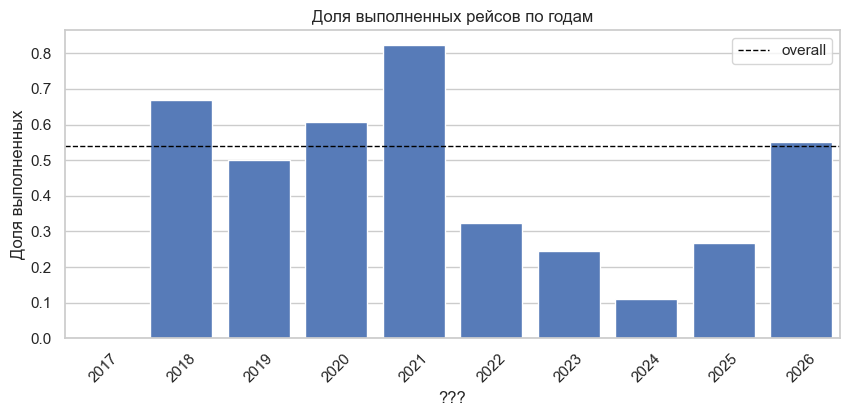

In [4]:
yearly = (
    df.groupby("year")
    .agg(
        rows=(target, "size"),
        completion_rate=(target, "mean"),
        completed=(target, "sum"),
    )
    .reset_index()
)
yearly["cancelled"] = yearly["rows"] - yearly["completed"]
display(yearly.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=yearly, x="year", y="completion_rate", color="#4777c8", ax=ax)
ax.axhline(df[target].mean(), color="black", linestyle="--", linewidth=1, label="overall")
ax.set_title("Доля выполненных рейсов по годам")
ax.set_xlabel("???")
ax.set_ylabel("Доля выполненных")
ax.legend()
plt.xticks(rotation=45)
plt.show()

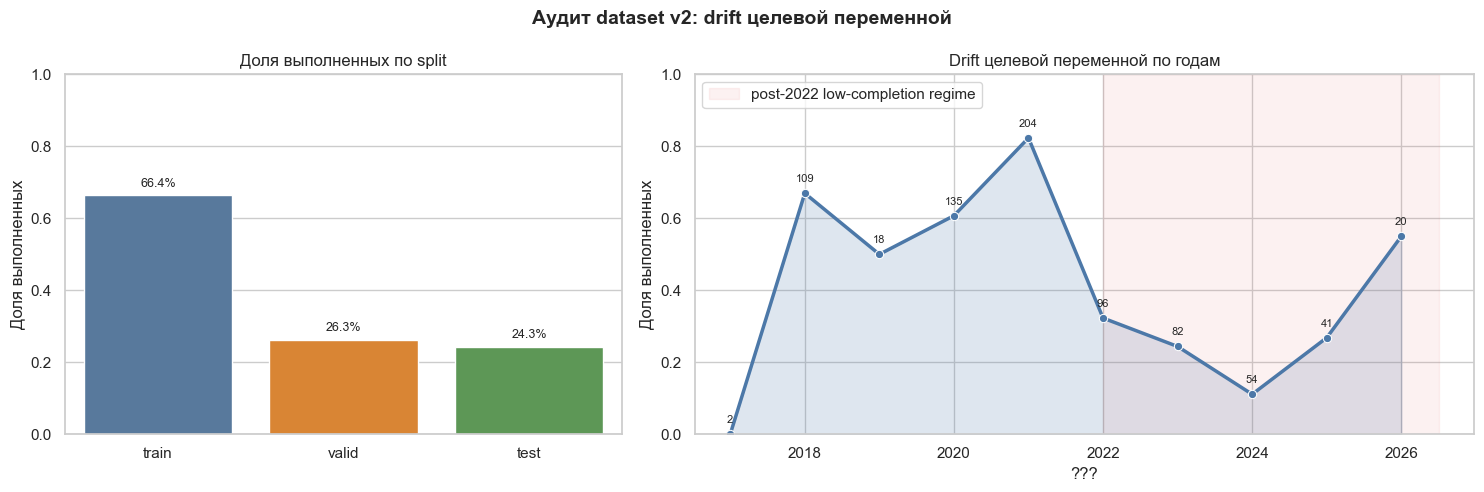

In [5]:
# Split and yearly visual audit
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 1.4]})

split_palette = {"train": "#4c78a8", "valid": "#f58518", "test": "#54a24b"}
plot_split = split_summary.copy()
sns.barplot(
    data=plot_split,
    x="dataset_split",
    y="completion_rate",
    hue="dataset_split",
    palette=split_palette,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Доля выполненных по split")
axes[0].set_xlabel("")
axes[0].set_ylabel("Доля выполненных")
axes[0].set_ylim(0, 1)
for patch, value in zip(axes[0].patches, plot_split["completion_rate"]):
    axes[0].annotate(
        f"{value:.1%}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 4),
        textcoords="offset points",
    )

plot_yearly = yearly.copy()
plot_yearly["cancelled_rate"] = 1 - plot_yearly["completion_rate"]
axes[1].fill_between(plot_yearly["year"], plot_yearly["completion_rate"], color="#4c78a8", alpha=0.18)
sns.lineplot(data=plot_yearly, x="year", y="completion_rate", marker="o", linewidth=2.5, color="#4c78a8", ax=axes[1])
axes[1].axvspan(2022, 2026.5, color="#e45756", alpha=0.08, label="post-2022 low-completion regime")
axes[1].set_title("Drift целевой переменной по годам")
axes[1].set_xlabel("???")
axes[1].set_ylabel("Доля выполненных")
axes[1].set_ylim(0, 1)
axes[1].legend(loc="best")
for _, row in plot_yearly.iterrows():
    axes[1].annotate(int(row["rows"]), (row["year"], row["completion_rate"]), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

fig.suptitle("Аудит dataset v2: drift целевой переменной", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Промежуточный вывод.** Если completion rate резко меняется между периодами, обычный ML benchmark может выбрать модель, которая учит период/источник данных, а не физику погоды. Поэтому `year` и похожие period proxies не должны быть базовыми production-признаками dataset v2.

## 3. Источники разметки и post-fact поля

Проверяем, менялись ли источники label-ов и confidence по периодам. Эти поля полезны для аудита, но не должны попадать в признаки модели: пользователь не знает `reason_class`, `message_count`, `label_confidence` или `event_date_sources` до факта.

In [6]:
def source_group(value):
    text = str(value or "").lower()
    if "manual" in text:
        return "manual"
    if "historical" in text:
        return "historical"
    if "telegram" in text:
        return "telegram"
    if "text" in text:
        return "text_extracted"
    if not text or text == "nan":
        return "missing"
    return "other"


df["source_group"] = df["event_date_sources"].map(source_group)

source_by_split = pd.crosstab(df["dataset_split"], df["source_group"], normalize="index").round(4)
confidence_by_split = pd.crosstab(df["dataset_split"], df["label_confidence"], normalize="index").round(4)
reason_by_split = pd.crosstab(df["dataset_split"], df["reason_class"], normalize="index").round(4)

print("Source group share by split")
display(source_by_split)
print("Label confidence share by split")
display(confidence_by_split)
print("Top reason class share by split")
display(reason_by_split.reindex(reason_by_split.mean().sort_values(ascending=False).head(12).index, axis=1))

Source group share by split


source_group,historical,manual,other,text_extracted
dataset_split,,,,
test,0.0609,0.1565,0.4783,0.3043
train,0.0357,0.0226,0.4305,0.5113
valid,0.0263,0.0702,0.5000,0.4035


Label confidence share by split


label_confidence,high,low,medium
dataset_split,,,
test,0.9652,0.0174,0.0174
train,0.9868,0.0019,0.0113
valid,0.9561,0.0000,0.0439


Top reason class share by split


reason_class,fog_likely,unknown,wind_storm_likely,weather,wind_storm,unknown_cancel_reason,fog,unknown;unknown_delay_reason,schedule,technical,unknown_cancel_reason;unknown,unknown_delay_reason;unknown_cancel_reason
dataset_split,,,,,,,,,,,,
test,0.3565,0.1913,0.2609,0.0957,0.0261,0.0087,0.0261,0.0261,0.0000,0.0000,0.0087,0.0000
train,0.2575,0.5188,0.1410,0.0075,0.0188,0.0244,0.0075,0.0000,0.0132,0.0019,0.0000,0.0038
valid,0.4386,0.2018,0.2895,0.0088,0.0088,0.0175,0.0088,0.0088,0.0088,0.0088,0.0000,0.0000


In [7]:
metadata_cols = [
    "status",
    "label_confidence",
    "reason_class",
    "message_count",
    "transport_types",
    "event_date_sources",
    "data_version",
    "training_data_version",
    "source_group",
]

metadata_audit = []
for col in metadata_cols:
    if col not in df.columns:
        continue
    metadata_audit.append(
        {
            "column": col,
            "unique_values": int(df[col].nunique(dropna=True)),
            "missing_rate": float(df[col].isna().mean()),
            "v2_role": "audit_only_post_fact_or_source_metadata",
            "model_feature": False,
        }
    )
metadata_audit = pd.DataFrame(metadata_audit)
metadata_audit

,column,unique_values,missing_rate,v2_role,model_feature
0,status,2,0.0,audit_only_post_fact_or_source_metadata,False
1,label_confidence,3,0.0,audit_only_post_fact_or_source_metadata,False
2,reason_class,15,0.0,audit_only_post_fact_or_source_metadata,False
3,message_count,28,0.0,audit_only_post_fact_or_source_metadata,False
4,transport_types,3,0.0,audit_only_post_fact_or_source_metadata,False
5,event_date_sources,25,0.0,audit_only_post_fact_or_source_metadata,False
6,data_version,1,0.0,audit_only_post_fact_or_source_metadata,False
7,training_data_version,1,0.0,audit_only_post_fact_or_source_metadata,False
8,source_group,4,0.0,audit_only_post_fact_or_source_metadata,False


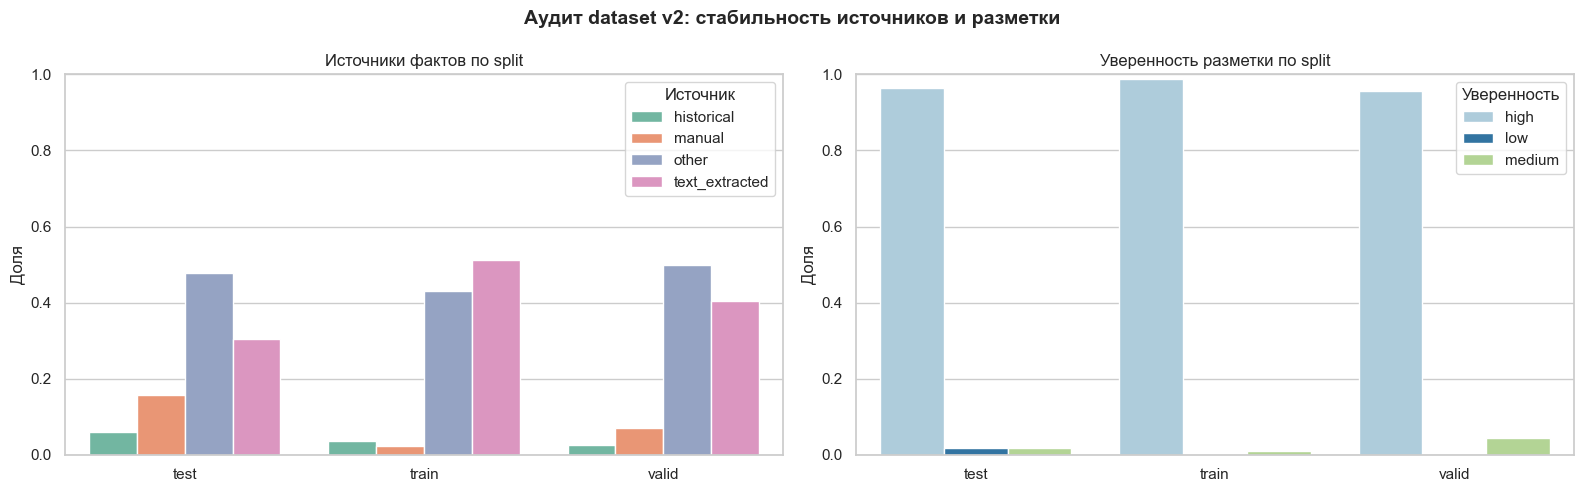

In [8]:
# Source and label metadata visual audit
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

source_plot = source_by_split.reset_index().melt(id_vars="dataset_split", var_name="source_group", value_name="share")
sns.barplot(
    data=source_plot,
    x="dataset_split",
    y="share",
    hue="source_group",
    ax=axes[0],
    palette="Set2",
)
axes[0].set_title("Источники фактов по split")
axes[0].set_xlabel("")
axes[0].set_ylabel("Доля")
axes[0].set_ylim(0, 1)
axes[0].legend(title="Источник", loc="upper right")

confidence_plot = confidence_by_split.reset_index().melt(id_vars="dataset_split", var_name="label_confidence", value_name="share")
sns.barplot(
    data=confidence_plot,
    x="dataset_split",
    y="share",
    hue="label_confidence",
    ax=axes[1],
    palette="Paired",
)
axes[1].set_title("Уверенность разметки по split")
axes[1].set_xlabel("")
axes[1].set_ylabel("Доля")
axes[1].set_ylim(0, 1)
axes[1].legend(title="Уверенность", loc="upper right")

fig.suptitle("Аудит dataset v2: стабильность источников и разметки", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Доступность погодных признаков

Главная проблема v1: visibility появилась неравномерно. Это делает часть погодных признаков proxy для периода. Dataset v2 должен явно разделять:

- фактическую историческую погоду дня для offline weather-risk анализа;
- forecast snapshot, доступный на момент production-прогноза;
- missingness/period artifacts, которые нельзя бездумно отдавать модели.

dataset_split,test,train,valid
feature,,,
khomutovo_cloud_cover_low_mean,0.0,0.0000,0.0
khomutovo_relative_humidity_2m_mean,0.0,0.0000,0.0
khomutovo_visibility_min,0.0,0.5921,0.0
mendeleyevo_cloud_cover_low_mean,0.0,0.0000,0.0
mendeleyevo_dew_point_spread_mean,0.0,0.0000,0.0
mendeleyevo_relative_humidity_2m_mean,0.0,0.0000,0.0
mendeleyevo_visibility_mean,0.0,0.5921,0.0
mendeleyevo_visibility_min,0.0,0.5921,0.0
mendeleyevo_weather_code_mode,0.0,0.0000,0.0


,year,rows,visibility_available,completion_rate
0,2017,2,0.00,0.0000
1,2018,109,0.00,0.6697
2,2019,18,0.00,0.5000
3,2020,135,0.00,0.6074
4,2021,204,0.75,0.8235
5,2022,96,1.00,0.3229
6,2023,82,1.00,0.2439
7,2024,54,1.00,0.1111
8,2025,41,1.00,0.2683
9,2026,20,1.00,0.5500


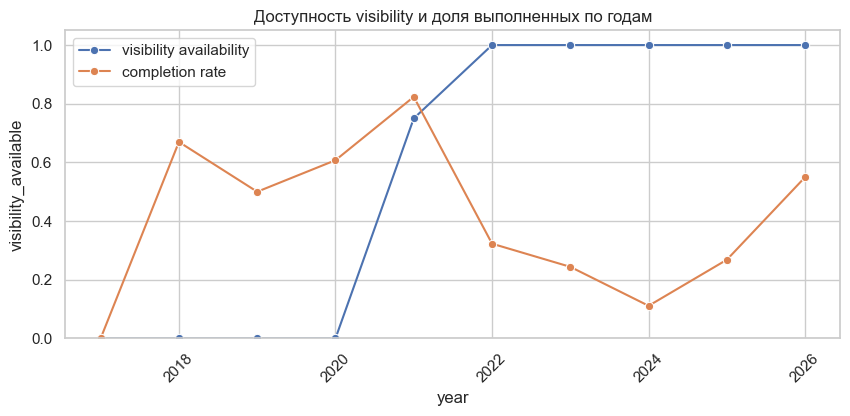

In [9]:
key_weather_cols = [
    "mendeleyevo_visibility_min",
    "mendeleyevo_visibility_mean",
    "mendeleyevo_cloud_cover_low_mean",
    "mendeleyevo_relative_humidity_2m_mean",
    "mendeleyevo_dew_point_spread_mean",
    "mendeleyevo_wind_gusts_10m_max",
    "mendeleyevo_weather_code_mode",
    "khomutovo_visibility_min",
    "khomutovo_cloud_cover_low_mean",
    "khomutovo_relative_humidity_2m_mean",
]
key_weather_cols = [col for col in key_weather_cols if col in df.columns]

missing_by_split = (
    df.groupby("dataset_split")[key_weather_cols]
    .apply(lambda part: part.isna().mean())
    .reset_index()
)
missing_long = missing_by_split.melt(id_vars="dataset_split", var_name="feature", value_name="missing_rate")
display(missing_long.pivot(index="feature", columns="dataset_split", values="missing_rate").round(4))

visibility_by_year = (
    df.groupby("year")
    .agg(
        rows=(target, "size"),
        visibility_available=("mendeleyevo_visibility_min", lambda s: s.notna().mean()),
        completion_rate=(target, "mean"),
    )
    .reset_index()
)
display(visibility_by_year.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=visibility_by_year, x="year", y="visibility_available", marker="o", ax=ax, label="visibility availability")
sns.lineplot(data=visibility_by_year, x="year", y="completion_rate", marker="o", ax=ax, label="completion rate")
ax.set_ylim(0, 1.05)
ax.set_title("Доступность visibility и доля выполненных по годам")
plt.xticks(rotation=45)
plt.show()

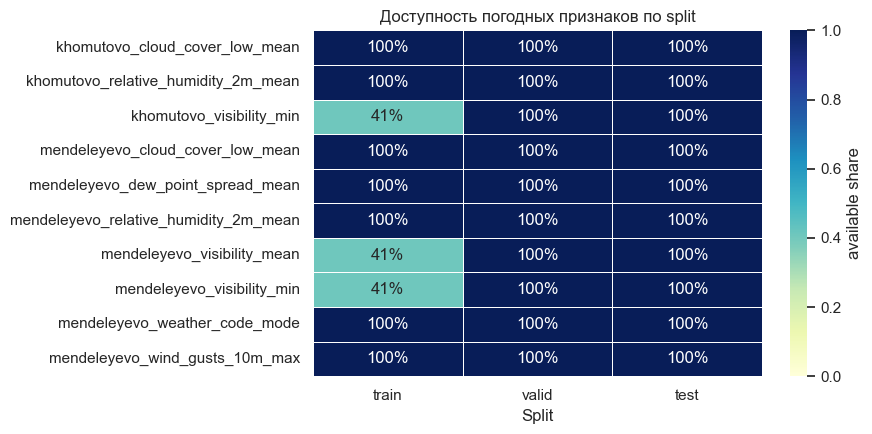

In [10]:
# Weather coverage heatmap
coverage_matrix = 1 - missing_long.pivot(index="feature", columns="dataset_split", values="missing_rate")
ordered_cols = [col for col in ["train", "valid", "test"] if col in coverage_matrix.columns]
coverage_matrix = coverage_matrix[ordered_cols]

fig, ax = plt.subplots(figsize=(9, max(4, len(coverage_matrix) * 0.45)))
sns.heatmap(
    coverage_matrix,
    annot=True,
    fmt=".0%",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "available share"},
    ax=ax,
)
ax.set_title("Доступность погодных признаков по split")
ax.set_xlabel("Split")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Feature registry для dataset v2

Фиксируем, какие признаки являются безопасными, какие нужны только для аудита, а какие требуют отдельного production replay. Это важнее, чем сразу запускать RF/LogReg: без registry эксперимент снова начнет сравнивать модели на неоднородной смеси признаков.

In [11]:
def classify_feature(column: str) -> tuple[str, bool, str]:
    if column in {"is_flight_completed"}:
        return "target", False, "target label"
    if column == "date":
        return "id", False, "date identifier, not a model feature"
    if column in metadata_cols:
        return "audit_only_post_fact_or_source_metadata", False, "available only after fact or source metadata"
    if column == "year":
        return "period_proxy", False, "encodes temporal period and source regime"
    if column == "dataset_split":
        return "audit_only_split", False, "evaluation split marker"
    if column.endswith("_missing"):
        return "period_missingness_proxy", False, "missingness can encode data period"
    if "visibility" in column:
        return "weather_actual_daily_with_coverage_risk", True, "keep for offline weather analysis; audit coverage by period"
    if column.startswith("mendeleyevo_") or column.startswith("khomutovo_"):
        return "weather_actual_daily", True, "actual historical weather for target day; not production forecast snapshot"
    if column.startswith("prev_") or column in {
        "same_month_past_completed_rate",
        "same_decade_past_completed_rate",
        "days_since_last_cancelled",
        "cancelled_streak_before",
        "completed_streak_before",
    }:
        return "rolling_history_pre_target", True, "safe for day-level offline; production needs run_date-aware replay"
    if column in {
        "month",
        "day",
        "day_of_year",
        "month_decade",
        "season",
        "day_of_week",
        "is_weekend",
        "day_of_year_sin",
        "day_of_year_cos",
        "month_sin",
        "month_cos",
    }:
        return "calendar_seasonality", True, "available before prediction"
    return "other_review_required", False, "not automatically approved"


registry_rows = []
for column in df.columns:
    role, include, note = classify_feature(column)
    registry_rows.append(
        {
            "column": column,
            "role": role,
            "include_in_day_level_dataset_v2": include,
            "missing_rate": round(float(df[column].isna().mean()), 6),
            "unique_values": int(df[column].nunique(dropna=True)),
            "note": note,
        }
    )

feature_registry = pd.DataFrame(registry_rows)
feature_registry.to_csv(FEATURE_REGISTRY_PATH, index=False, encoding="utf-8-sig")

role_summary = (
    feature_registry.groupby(["role", "include_in_day_level_dataset_v2"])
    .size()
    .reset_index(name="columns")
    .sort_values(["include_in_day_level_dataset_v2", "columns"], ascending=[False, False])
)
display(role_summary)
print("feature_registry:", FEATURE_REGISTRY_PATH)

,role,include_in_day_level_dataset_v2,columns
7,weather_actual_daily,True,70
2,calendar_seasonality,True,11
5,rolling_history_pre_target,True,10
8,weather_actual_daily_with_coverage_risk,True,4
0,audit_only_post_fact_or_source_metadata,False,9
1,audit_only_split,False,1
3,id,False,1
4,period_proxy,False,1
6,target,False,1


feature_registry: C:\Users\Владимир Королев\PycharmProjects\flyforecast\data\interim\training\dataset_v2_audit\feature_registry.csv


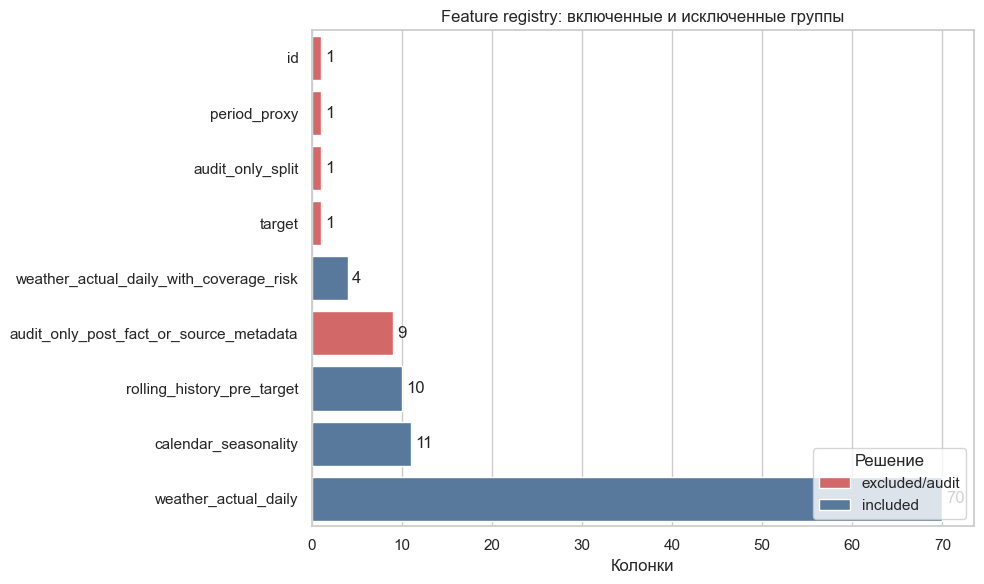

In [12]:
# Feature registry visual summary
role_plot = role_summary.copy().sort_values("columns", ascending=True)
role_plot["decision"] = np.where(role_plot["include_in_day_level_dataset_v2"], "included", "excluded/audit")

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=role_plot,
    y="role",
    x="columns",
    hue="decision",
    dodge=False,
    palette={"included": "#4c78a8", "excluded/audit": "#e45756"},
    ax=ax,
)
ax.set_title("Feature registry: включенные и исключенные группы")
ax.set_xlabel("Колонки")
ax.set_ylabel("")
ax.legend(title="Решение", loc="lower right")
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()

In [13]:
model_feature_cols = feature_registry.loc[
    feature_registry["include_in_day_level_dataset_v2"],
    "column",
].tolist()

recommended_feature_sets = {
    "day_level_v2_features": model_feature_cols,
    "day_level_v2_no_visibility_features": [col for col in model_feature_cols if "visibility" not in col],
    "excluded_post_fact_or_source_metadata": [
        col for col in feature_registry.loc[
            feature_registry["role"].eq("audit_only_post_fact_or_source_metadata"),
            "column",
        ].tolist()
    ],
    "excluded_period_proxy": [
        col for col in feature_registry.loc[
            feature_registry["role"].isin(["period_proxy", "period_missingness_proxy"]),
            "column",
        ].tolist()
    ],
}

RECOMMENDED_FEATURES_PATH.write_text(json.dumps(recommended_feature_sets, ensure_ascii=False, indent=2), encoding="utf-8")

print("day_level_v2_features:", len(recommended_feature_sets["day_level_v2_features"]))
print("day_level_v2_no_visibility_features:", len(recommended_feature_sets["day_level_v2_no_visibility_features"]))
print("recommended_feature_sets:", RECOMMENDED_FEATURES_PATH)

feature_registry[feature_registry["include_in_day_level_dataset_v2"]].head(20)

day_level_v2_features: 95
day_level_v2_no_visibility_features: 91
recommended_feature_sets: C:\Users\Владимир Королев\PycharmProjects\flyforecast\data\interim\training\dataset_v2_audit\recommended_feature_sets.json


,column,role,include_in_day_level_dataset_v2,missing_rate,unique_values,note
9,month,calendar_seasonality,True,0.0,12,available before prediction
10,day,calendar_seasonality,True,0.0,31,available before prediction
11,day_of_year,calendar_seasonality,True,0.0,333,available before prediction
12,month_decade,calendar_seasonality,True,0.0,4,available before prediction
13,season,calendar_seasonality,True,0.0,4,available before prediction
15,khomutovo_temperature_2m_mean,weather_actual_daily,True,0.0,724,actual historical weather for target day; not ...
16,khomutovo_temperature_2m_min,weather_actual_daily,True,0.0,330,actual historical weather for target day; not ...
17,khomutovo_temperature_2m_max,weather_actual_daily,True,0.0,328,actual historical weather for target day; not ...
18,khomutovo_relative_humidity_2m_mean,weather_actual_daily,True,0.0,481,actual historical weather for target day; not ...
19,khomutovo_relative_humidity_2m_max,weather_actual_daily,True,0.0,35,actual historical weather for target day; not ...


## 6. Сборка day-level dataset v2

Это не production replay и не финальный ML benchmark. Это очищенный day-level dataset для следующего offline benchmark:

- одна строка = target date;
- удалены post-fact/source metadata;
- удален `year` как сильный period proxy;
- visibility оставлена, но помечена в feature registry как признак с coverage risk;
- отдельно сохранен список признаков без visibility.

Для production inference такой dataset всё ещё недостаточен: там нужен `(run_date, target_date, horizon_days)` и forecast snapshot на момент run date.

In [14]:
dataset_v2_day = df[["date", target, "dataset_split"] + model_feature_cols].copy()
dataset_v2_day = dataset_v2_day.loc[:, ~dataset_v2_day.columns.duplicated()].copy()
dataset_v2_day.to_csv(DATASET_V2_DAY_PATH, index=False, encoding="utf-8-sig")

v2_summary = {
    "rows": len(dataset_v2_day),
    "columns": len(dataset_v2_day.columns),
    "feature_columns": len(dataset_v2_day.columns) - 3,
    "date_min": str(dataset_v2_day["date"].min().date()),
    "date_max": str(dataset_v2_day["date"].max().date()),
    "path": str(DATASET_V2_DAY_PATH),
}
print(json.dumps(v2_summary, ensure_ascii=False, indent=2))
dataset_v2_day.head()

{
  "rows": 761,
  "columns": 98,
  "feature_columns": 95,
  "date_min": "2017-12-13",
  "date_max": "2026-05-26",
  "path": "C:\\Users\\Владимир Королев\\PycharmProjects\\flyforecast\\data\\processed\\training_dataset_v2_day.csv"
}


,date,is_flight_completed,dataset_split,month,day,day_of_year,month_decade,season,khomutovo_temperature_2m_mean,khomutovo_temperature_2m_min,...,prev_1_completed,prev_3_cancelled_count,prev_7_cancelled_count,prev_14_completed_rate,prev_30_completed_rate,same_month_past_completed_rate,same_decade_past_completed_rate,days_since_last_cancelled,cancelled_streak_before,completed_streak_before
0,2017-12-13,0,train,12,13,347,2,winter,0.0500,-2.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,2017-12-26,0,train,12,26,360,3,winter,-9.6750,-10.8,...,0.0,1.0,1.0,NaN,NaN,0.0,NaN,13.0,1,0
2,2018-01-10,0,train,1,10,10,1,winter,-5.5208,-8.0,...,0.0,2.0,2.0,NaN,NaN,NaN,NaN,15.0,2,0
3,2018-01-11,0,train,1,11,11,2,winter,-9.8708,-12.1,...,0.0,3.0,3.0,0.0,NaN,0.0,NaN,1.0,3,0
4,2018-01-23,0,train,1,23,23,3,winter,-13.6000,-18.0,...,0.0,3.0,4.0,0.0,NaN,0.0,NaN,12.0,4,0


## 7. Production replay dataset v2

Production replay — отдельный universe. Здесь одна строка = `(run_date, target_date, horizon_days)`, а признаки должны быть snapshot-ами, доступными на момент запуска прогноза.

Если рядом есть `current_baseline_007_historical_forecast_details.csv`, собираем локальный replay dataset v2 из monitor/backtest details. Этот файл маленький и нужен не для обучения большой ML-модели, а для проверки production decision policy и будущего challenger-а.

In [15]:
if BACKTEST_DETAILS_PATH.exists():
    replay = pd.read_csv(BACKTEST_DETAILS_PATH)
    replay_cols = [
        "prediction_id",
        "run_date",
        "target_date",
        "horizon_days",
        "horizon_bucket",
        "outcome_status",
        "outcome_binary",
        "historical_probability_flight",
        "decade_probability_flight",
        "backtest_weather_source",
        "backtest_weather_available",
        "flight_window_available",
        "flight_window_start_hour",
        "flight_window_end_hour",
        "flight_window_hours",
        "visibility",
        "weather_code",
        "wind_gusts_10m",
        "cloud_cover_low",
        "fog_low_cloud_risk_level",
        "original_model_version",
        "original_probability_flight",
        "original_decision",
        "original_hit",
        "backtest_model_version",
        "backtest_probability_flight",
        "backtest_decision",
        "backtest_hit",
        "backtest_brier_score",
        "backtest_absolute_error",
    ]
    replay_cols = [col for col in replay_cols if col in replay.columns]
    replay_v2 = replay[replay_cols].copy()
    replay_v2.to_csv(PRODUCTION_REPLAY_V2_PATH, index=False, encoding="utf-8-sig")

    replay_summary = {
        "rows": len(replay_v2),
        "date_min": replay_v2["target_date"].min(),
        "date_max": replay_v2["target_date"].max(),
        "accuracy": round(float(replay_v2["backtest_hit"].mean()), 4),
        "false_yes": int(((replay_v2["backtest_decision"] == "yes") & (replay_v2["outcome_binary"] == 0)).sum()),
        "false_no": int(((replay_v2["backtest_decision"] == "no") & (replay_v2["outcome_binary"] == 1)).sum()),
        "path": str(PRODUCTION_REPLAY_V2_PATH),
    }
    print(json.dumps(replay_summary, ensure_ascii=False, indent=2))
    display(replay_v2.head())
else:
    print("Backtest details CSV not found:", BACKTEST_DETAILS_PATH)
    print("Run pipelines/evaluation/backtest_current_baseline.py on the server and copy the CSV into data/interim/evaluation/backtests/.")

{
  "rows": 70,
  "date_min": "2026-05-20",
  "date_max": "2026-05-30",
  "accuracy": 0.9143,
  "false_yes": 6,
  "false_no": 0,
  "path": "C:\\Users\\Владимир Королев\\PycharmProjects\\flyforecast\\data\\interim\\evaluation\\backtests\\production_replay_dataset_v2.csv"
}


,prediction_id,run_date,target_date,horizon_days,horizon_bucket,outcome_status,outcome_binary,historical_probability_flight,decade_probability_flight,backtest_weather_source,...,original_model_version,original_probability_flight,original_decision,original_hit,backtest_model_version,backtest_probability_flight,backtest_decision,backtest_hit,backtest_brier_score,backtest_absolute_error
0,1,2026-05-20,2026-05-20,0,0,completed,1,0.7143,0.7097,open-meteo-historical-forecast-backtest,...,mvp-baseline-001,0.5627,yes,1,mvp-baseline-007,0.8227,yes,1,0.031435,0.1773
1,2,2026-05-20,2026-05-21,1,1-3,completed,1,0.6875,0.6667,open-meteo-historical-forecast-backtest,...,mvp-baseline-001,0.5302,no,0,mvp-baseline-007,0.7702,yes,1,0.052808,0.2298
2,3,2026-05-20,2026-05-22,2,1-3,completed,1,0.6875,0.6667,open-meteo-historical-forecast-backtest,...,mvp-baseline-001,0.6102,yes,1,mvp-baseline-007,0.8002,yes,1,0.039920,0.1998
3,4,2026-05-20,2026-05-23,3,1-3,completed,1,0.6790,0.6667,open-meteo-historical-forecast-backtest,...,mvp-baseline-001,0.6047,yes,1,mvp-baseline-007,0.7947,yes,1,0.042148,0.2053
4,5,2026-05-20,2026-05-24,4,4-7,completed,1,0.6790,0.6667,open-meteo-historical-forecast-backtest,...,mvp-baseline-001,0.5247,no,0,mvp-baseline-007,0.7847,yes,1,0.046354,0.2153


## 8. Исключения признаков и leakage checklist

Feature registry полезен сам по себе, но для быстрого ревью нужен компактный список решений: что исключено, почему исключено, и какие признаки оставлены с риском. Этот блок делает audit notebook проверяемым без чтения всех 95 признаков вручную.

In [16]:
excluded_or_risky = feature_registry[
    (~feature_registry["include_in_day_level_dataset_v2"])
    | feature_registry["role"].eq("weather_actual_daily_with_coverage_risk")
].copy()

exclusion_summary = (
    excluded_or_risky.groupby("role")
    .agg(
        columns=("column", "size"),
        included_in_day_v2=("include_in_day_level_dataset_v2", "max"),
        examples=("column", lambda values: ", ".join(list(values)[:8])),
        note=("note", "first"),
    )
    .reset_index()
    .sort_values(["included_in_day_v2", "columns"], ascending=[True, False])
)
display(exclusion_summary)

leakage_checks = pd.DataFrame(
    [
        {
            "check": "date/id not used as model feature",
            "status": "yes" if "date" not in model_feature_cols else "no",
            "evidence": "date role=id; отсутствует в model_feature_cols",
        },
        {
            "check": "year excluded as period proxy",
            "status": "yes" if "year" not in model_feature_cols else "no",
            "evidence": "year role=period_proxy",
        },
        {
            "check": "dataset_split excluded from features",
            "status": "yes" if "dataset_split" not in model_feature_cols else "no",
            "evidence": "split marker используется только для evaluation protocol",
        },
        {
            "check": "post-fact status/reason/source metadata excluded",
            "status": "yes" if not set(metadata_cols).intersection(model_feature_cols) else "no",
            "evidence": ", ".join(metadata_cols),
        },
        {
            "check": "missingness/period proxy excluded",
            "status": "yes" if not any(col.endswith("_missing") for col in model_feature_cols) else "no",
            "evidence": "missingness может кодировать период сбора данных",
        },
        {
            "check": "actual weather allowed only for day-level offline benchmark",
            "status": "yes",
            "evidence": "weather_actual_daily не равен forecast snapshot для production inference",
        },
        {
            "check": "production inference requires forecast snapshots",
            "status": "yes",
            "evidence": "для production replay нужна строка (run_date, target_date, horizon_days)",
        },
    ]
)
display(leakage_checks)

,role,columns,included_in_day_v2,examples,note
0,audit_only_post_fact_or_source_metadata,9,False,"status, label_confidence, reason_class, messag...",available only after fact or source metadata
1,audit_only_split,1,False,dataset_split,evaluation split marker
2,id,1,False,date,"date identifier, not a model feature"
3,period_proxy,1,False,year,encodes temporal period and source regime
4,target,1,False,is_flight_completed,target label
5,weather_actual_daily_with_coverage_risk,4,True,"khomutovo_visibility_mean, khomutovo_visibilit...",keep for offline weather analysis; audit cover...


,check,status,evidence
0,date/id not used as model feature,yes,date role=id; отсутствует в model_feature_cols
1,year excluded as period proxy,yes,year role=period_proxy
2,dataset_split excluded from features,yes,split marker используется только для evaluatio...
3,post-fact status/reason/source metadata excluded,yes,"status, label_confidence, reason_class, messag..."
4,missingness/period proxy excluded,yes,missingness может кодировать период сбора данных
5,actual weather allowed only for day-level offl...,yes,weather_actual_daily не равен forecast snapsho...
6,production inference requires forecast snapshots,yes,"для production replay нужна строка (run_date, ..."


## 9. Итоги аудита

Что зафиксировано:

- `training_dataset_v1.csv` нельзя считать нейтральной основой для нового benchmark без оговорок: completion rate падает с `66%` на train до примерно `26%` на valid и `24%` на test.
- Source/label metadata нужны для аудита, но не должны быть model features.
- `year` исключается из dataset v2 как period proxy.
- Post-fact поля `status`, `reason_class`, `message_count`, `label_confidence`, `event_date_sources` и другие source metadata исключаются из feature set.
- Visibility остается полезным погодным сигналом, но имеет coverage risk; следующий benchmark обязан сравнить feature set с visibility и без visibility.
- Day-level dataset v2 и production replay dataset v2 — разные сущности. Их нельзя смешивать в одном выводе о качестве модели.
- Production replay dataset на текущих `70` строках monitor backtest годится как smoke-test policy, но не как финальный validation universe для сравнения ML и baseline.

Созданные локальные артефакты:

- `data/processed/training_dataset_v2_day.csv` — очищенный day-level dataset для следующего offline benchmark;
- `data/interim/training/dataset_v2_audit/feature_registry.csv` — registry признаков и причин включения/исключения;
- `data/interim/training/dataset_v2_audit/recommended_feature_sets.json` — feature sets для следующего benchmark;
- `data/interim/evaluation/backtests/production_replay_dataset_v2.csv` — production replay dataset, если был доступен monitor backtest CSV.

Что делать дальше:

1. Сделать отдельный `02_offline_model_benchmark.ipynb` на `training_dataset_v2_day.csv`.
2. В benchmark обязательно сравнить:
   - seasonal baseline;
   - Logistic Regression;
   - Decision Tree;
   - RF full v2;
   - RF без visibility;
   - RF без period/missingness proxy.
3. Threshold tuning делать только на validation.
4. Test использовать один раз для финальной оценки.
5. Production replay вынести в отдельный notebook и не смешивать с offline ML benchmark.
